plots georeferenced UHI data 

In [2]:
import importlib
import sys
import os

sys.path.append(os.path.abspath("../"))

from utils.gref_pipeline import georef
from gref_pipeline import config

importlib.reload(georef)
from utils.gref_pipeline.georef import *

select transects

In [3]:
transect = load_transect(config.OUTPUT_FOLDER)
transect.list_files()

cube = transect.select_files(
    [
        "rad_uhi_20241029_115057_1",
        "rad_uhi_20241029_115057_2",
        "rad_uhi_20241029_115057_3",
        "rad_uhi_20241029_115057_4",
        "rad_uhi_20241029_115057_5",
        "rad_uhi_20241029_115057_6",
    ]
)
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_1
  rad_uhi_20241029_115057_1: Using GRIDDED format (T=1333, S=968)
   • rad_uhi_20241029_115057_2
  rad_uhi_20241029_115057_2: Using GRIDDED format (T=1946, S=968)
   • rad_uhi_20241029_115057_3
  rad_uhi_20241029_115057_3: Using GRIDDED format (T=2227, S=968)
   • rad_uhi_20241029_115057_4
  rad_uhi_20241029_115057_4: Using GRIDDED format (T=2463, S=968)
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using G

consider using qt or inline → the interactive mode for coordinates only work with qt

In [3]:
# %matplotlib qt

In [4]:
%matplotlib inline

plot complete georeferenced uhi

In [5]:
# ========================================================================
# Full, self-contained module for georeferenced plotting with timestamps
# - Reads timestamps from HDF5 at "processed/radiance/timestamps" (preferred)
#   with safe fallbacks ("processed/timestamp", "timestamp", "timestamps")
# - Shows UTC time range for the plotted slice (whole plot or track_start/end)
# - Includes required helpers to avoid NameError (_ecef_to_ned_arrays, etc.)
# - Keeps the rest of logic/args/behavior intact
# ========================================================================

import os
import sys
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import h5py
import matplotlib.pyplot as plt
from pyproj import Transformer

# Optional config (if present in your environment). If not, it's fine.
try:
    from gref_pipeline import config  # noqa: F401
except Exception:
    config = None  # type: ignore


# ------------------------- CRS helpers -------------------------


def _ecef_of_geodetic(
    lat_deg: float, lon_deg: float, h_m: float
) -> Tuple[float, float, float]:
    tf = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
    x0, y0, z0 = tf.transform(lon_deg, lat_deg, h_m)
    return float(x0), float(y0), float(z0)


def _ecef_to_ned_arrays(x, y, z, lat0, lon0, h0):
    """Vectorized ECEF -> NED (returns north, east, down) relative to (lat0, lon0, h0)."""
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    x0, y0, z0 = _ecef_of_geodetic(lat0, lon0, h0)

    dx = x - x0
    dy = y - y0
    dz = z - z0

    lat = np.radians(lat0)
    lon = np.radians(lon0)

    sL = np.sin(lat)
    cL = np.cos(lat)
    sO = np.sin(lon)
    cO = np.cos(lon)

    n = (-sL * cO) * dx + (-sL * sO) * dy + (cL) * dz
    e = (-sO) * dx + (cO) * dy
    d = (-cL * cO) * dx + (-cL * sO) * dy + (-sL) * dz
    return n, e, d


def unix_to_utc(timestamp):
    """Convert unix timestamp to UTC string format."""
    from datetime import datetime

    try:
        return datetime.utcfromtimestamp(float(timestamp)).strftime(
            "%Y-%m-%d %H:%M:%S UTC"
        )
    except (ValueError, OSError, TypeError):
        return "N/A"


# ------------------------- Data wrappers -------------------------


class GeoFile:
    """
    Wraps a single H5 file containing (new pipeline outputs):
      - processed/radiance/dataCube(_corrected): (T, S, B)
      - processed/radiance/calibration/spectral/band2Wavelength
      - processed/georef/points_ecef_crs: (T, S, 3)  [preferred]
        (or legacy flattened: (N,3) + processed/georef/frame_indices & ray_indices)
      - processed/radiance/timestamps: (T,)  [preferred for time]
    """

    # dataset names
    DSET_RGB_MAIN = "processed/radiance/dataCube"
    DSET_RGB_CORR = "processed/radiance/dataCube_corrected"
    DSET_WAVELEN = "processed/radiance/calibration/spectral/band2Wavelength"

    DSET_G_POINTS = "processed/georef/points_ecef_crs"  # preferred
    DSET_G_POINTS_ALT = "processed/georef/points_ecef"  # legacy fallback

    # Legacy flattened format
    DSET_G_FRAMES = "processed/georef/frame_indices"
    DSET_G_PIXELS = "processed/georef/ray_indices"
    # New gridded indices (sometimes present)
    DSET_G_FRAMES_GRID = "processed/georef/frame_nr_grid"
    DSET_G_PIXELS_GRID = "processed/georef/pixel_nr_grid"

    # Timestamp datasets (preferred first)
    DSET_TIMESTAMPS = [
        "processed/radiance/timestamps",  # << primary path
        "processed/timestamp",
        "timestamp",
        "timestamps",
    ]

    def __init__(self, path: str, use_corrected: bool = False):
        self.path = path
        self.name = os.path.splitext(os.path.basename(path))[0]
        self.use_corrected = use_corrected

        self.shape: Optional[Tuple[int, int, int]] = None  # (T, S, B)
        self.wavelengths: Optional[np.ndarray] = None
        self.has_georef: bool = False
        self.timestamps: Optional[np.ndarray] = None  # Unix timestamps per track

        self._check()

    def _check(self):
        try:
            with h5py.File(self.path, "r") as f:
                # radiance cube
                dset_cube = (
                    self.DSET_RGB_CORR if self.use_corrected else self.DSET_RGB_MAIN
                )
                if dset_cube not in f and self.DSET_RGB_MAIN in f:
                    dset_cube = self.DSET_RGB_MAIN
                    self.use_corrected = False
                if dset_cube in f:
                    self.shape = tuple(f[dset_cube].shape)  # (T,S,B)
                else:
                    self.shape = None

                # wavelengths
                self.wavelengths = (
                    f[self.DSET_WAVELEN][()] if self.DSET_WAVELEN in f else None
                )

                # georef presence (grid is mainline, legacy points also accepted)
                pts_ok = (self.DSET_G_POINTS in f) or (self.DSET_G_POINTS_ALT in f)
                self.has_georef = bool(pts_ok)

                # timestamps (prefer processed/radiance/timestamps)
                for ts_path in self.DSET_TIMESTAMPS:
                    if ts_path in f:
                        self.timestamps = np.asarray(f[ts_path][()]).ravel()
                        break

        except Exception as e:
            print(f"⚠️  Could not read metadata from {self.name}: {e}")
            self.shape = None
            self.wavelengths = None
            self.has_georef = False
            self.timestamps = None

    def _band_index(self, wl_nm: float) -> Optional[int]:
        if self.wavelengths is None:
            return None
        return int(np.argmin(np.abs(self.wavelengths - wl_nm)))

    def build_grids_and_rgb(
        self, red_wl=654.2, green_wl=560.0, blue_wl=440.3
    ) -> Dict[str, np.ndarray]:
        """
        Returns a dictionary with:
            X_ecef, Y_ecef, Z_ecef : (T, S)
            R, G, B                 : (T, S) floats (NaN where no hit)
            T, S                    : ints
        All grids have matching (T, S) derived from the radiance cube.
        """
        if self.shape is None:
            raise RuntimeError(f"{self.name}: radiance cube not found")
        T, S, B = self.shape

        dset_cube = self.DSET_RGB_CORR if self.use_corrected else self.DSET_RGB_MAIN

        X = np.full((T, S), np.nan, dtype=np.float64)
        Y = np.full((T, S), np.nan, dtype=np.float64)
        Z = np.full((T, S), np.nan, dtype=np.float64)
        R = np.full((T, S), np.nan, dtype=np.float64)
        G = np.full((T, S), np.nan, dtype=np.float64)
        Bc = np.full((T, S), np.nan, dtype=np.float64)

        with h5py.File(self.path, "r") as f:
            # georef points
            if self.DSET_G_POINTS in f:
                P = f[self.DSET_G_POINTS][()]
            elif self.DSET_G_POINTS_ALT in f:
                P = f[self.DSET_G_POINTS_ALT][()]
            else:
                raise RuntimeError(f"{self.name}: no processed/georef points dataset")

            if P.ndim == 3 and P.shape[-1] == 3:
                # GRIDDED FORMAT: (T, S, 3)
                X[:, :], Y[:, :], Z[:, :] = P[..., 0], P[..., 1], P[..., 2]

                # band indices
                iR = self._band_index(red_wl)
                iG = self._band_index(green_wl)
                iB = self._band_index(blue_wl)
                if iR is None or iG is None or iB is None:
                    raise RuntimeError(f"{self.name}: wavelengths not available")

                data = f[dset_cube][()]  # (T,S,B)
                R[:, :], G[:, :], Bc[:, :] = data[..., iR], data[..., iG], data[..., iB]

                # mask invalid geometry
                invalid = ~(np.isfinite(X) & np.isfinite(Y) & np.isfinite(Z))
                R[invalid] = np.nan
                G[invalid] = np.nan
                Bc[invalid] = np.nan

            elif P.ndim == 2 and P.shape[1] == 3:
                # LEGACY FLAT: (N,3) + indices
                if (self.DSET_G_FRAMES in f) and (self.DSET_G_PIXELS in f):
                    frames = f[self.DSET_G_FRAMES][()].astype(int)
                    slits = f[self.DSET_G_PIXELS][()].astype(int)
                elif (self.DSET_G_FRAMES_GRID in f) and (self.DSET_G_PIXELS_GRID in f):
                    frames_grid = f[self.DSET_G_FRAMES_GRID][()]
                    slits_grid = f[self.DSET_G_PIXELS_GRID][()]
                    if frames_grid.ndim == 2:
                        valid = np.isfinite(P[:, 0])
                        frames = frames_grid.ravel()[valid].astype(int)
                        slits = slits_grid.ravel()[valid].astype(int)
                    else:
                        frames = frames_grid.astype(int)
                        slits = slits_grid.astype(int)
                else:
                    raise RuntimeError(
                        f"{self.name}: flat points require frame_indices & pixel_indices"
                    )
                if len(frames) != len(P) or len(slits) != len(P):
                    raise RuntimeError(f"{self.name}: georef arrays length mismatch")

                iR = self._band_index(red_wl)
                iG = self._band_index(green_wl)
                iB = self._band_index(blue_wl)
                if iR is None or iG is None or iB is None:
                    raise RuntimeError(f"{self.name}: wavelengths not available")

                data = f[dset_cube]  # lazy

                for i in range(len(P)):
                    t = int(frames[i])
                    s = int(slits[i])
                    if 0 <= t < T and 0 <= s < S:
                        X[t, s] = P[i, 0]
                        Y[t, s] = P[i, 1]
                        Z[t, s] = P[i, 2]
                        R[t, s] = data[t, s, iR]
                        G[t, s] = data[t, s, iG]
                        Bc[t, s] = data[t, s, iB]
            else:
                raise RuntimeError(f"{self.name}: unexpected georef shape {P.shape}")

        return dict(X_ecef=X, Y_ecef=Y, Z_ecef=Z, R=R, G=G, B=Bc, T=T, S=S)


# ------------------------- Transect containers -------------------------


class TransectDataSet:
    """Discovers H5s in a folder and exposes selection helpers."""

    def __init__(self, folder: str, use_corrected: bool = False):
        self.folder = folder
        self.use_corrected = use_corrected
        self.files: Dict[str, GeoFile] = {}
        self._discover()

    def _discover(self):
        if not os.path.isdir(self.folder):
            print(f"❌ Folder not found: {self.folder}")
            return
        for fn in sorted(os.listdir(self.folder)):
            if not fn.lower().endswith(".h5"):
                continue
            path = os.path.join(self.folder, fn)
            gf = GeoFile(path, use_corrected=self.use_corrected)
            if gf.shape is not None and gf.has_georef:
                self.files[gf.name] = gf
            else:
                if gf.shape is not None:
                    print(f"⚠️  {fn}: radiance found but no georef dataset – skipped")
                else:
                    print(f"⚠️  {fn}: no radiance cube – skipped")

    def list_files(self):
        print(
            f"\n📋 Files in {os.path.basename(self.folder)} (corrected={self.use_corrected}):"
        )
        for i, (name, gf) in enumerate(self.files.items(), 1):
            print(f"{i:2d}. {name}  | shape={gf.shape}  | has_georef={gf.has_georef}")
        if not self.files:
            print("  (none)")

    def select_files(self, names: List[str]) -> "CombinedTransectCube":
        missing = [n for n in names if n not in self.files]
        if missing:
            print(f"⚠️  Missing files: {missing}")
        chosen = [self.files[n] for n in names if n in self.files]
        if not chosen:
            raise ValueError("No valid files selected")
        return CombinedTransectCube(chosen, self.folder, self.use_corrected)

    def select_all_files(self) -> "CombinedTransectCube":
        return self.select_files(list(self.files.keys()))

    def select_files_by_pattern(self, pattern: str) -> "CombinedTransectCube":
        import fnmatch

        names = [n for n in self.files if fnmatch.fnmatch(n, pattern)]
        if not names:
            raise ValueError(f"No files match pattern: {pattern}")
        return self.select_files(names)


class CombinedTransectCube:
    """Combines multiple GeoFiles into a single logical cube along track."""

    def __init__(self, geofiles: List[GeoFile], folder: str, use_corrected: bool):
        self.geofiles = geofiles
        self.folder = folder
        self.use_corrected = use_corrected
        self.name = f"Combined_{os.path.basename(folder)}"
        self.file_boundaries = []  # list of dict with start_track etc.

        # combined grids (filled in on demand)
        self.X_ecef: Optional[np.ndarray] = None
        self.Y_ecef: Optional[np.ndarray] = None
        self.Z_ecef: Optional[np.ndarray] = None
        self.R: Optional[np.ndarray] = None
        self.G: Optional[np.ndarray] = None
        self.B: Optional[np.ndarray] = None
        self.wavelengths = geofiles[0].wavelengths if geofiles else None
        self.timestamps: Optional[np.ndarray] = None  # Combined timestamps

        self._build_combined()

    def _build_combined(self):
        print("🔄 Rebuilding grids from georef hits for selected files...")
        xs, ys, zs, rs, gs, bs = [], [], [], [], [], []
        timestamps_list = []
        T_accum = 0
        for gf in self.geofiles:
            print(f"   • {gf.name}")
            d = (
                gf.build_grids_and_rgb()
            )  # default RGB wavelengths; can re-run with kwargs in plot
            T, S = d["T"], d["S"]
            self.file_boundaries.append(
                {
                    "file": gf.name,
                    "start_track": T_accum,
                    "end_track": T_accum + T - 1,
                    "n_tracks": T,
                }
            )
            xs.append(d["X_ecef"])
            ys.append(d["Y_ecef"])
            zs.append(d["Z_ecef"])
            rs.append(d["R"])
            gs.append(d["G"])
            bs.append(d["B"])

            # Collect timestamps; prefer exact length T, else pad/truncate
            if gf.timestamps is not None:
                ts = np.asarray(gf.timestamps).ravel()
                if len(ts) == T:
                    timestamps_list.append(ts)
                elif len(ts) > T:
                    timestamps_list.append(ts[:T])
                else:
                    pad = np.full(T, np.nan, dtype=float)
                    pad[: len(ts)] = ts
                    timestamps_list.append(pad)
            else:
                timestamps_list.append(np.full(T, np.nan, dtype=float))

            T_accum += T

        # combine along track axis
        self.X_ecef = np.concatenate(xs, axis=0)
        self.Y_ecef = np.concatenate(ys, axis=0)
        self.Z_ecef = np.concatenate(zs, axis=0)
        self.R = np.concatenate(rs, axis=0)
        self.G = np.concatenate(gs, axis=0)
        self.B = np.concatenate(bs, axis=0)

        # Combine timestamps
        self.timestamps = (
            np.concatenate(timestamps_list, axis=0) if timestamps_list else None
        )

        print(f"✅ Combined shapes: X/Y/Z {self.X_ecef.shape}, RGB {self.R.shape}")

    def _rgb_from_wavelengths(self, Rnm, Gnm, Bnm, normalize):
        """Recompute R/G/B from requested wavelengths (without rebuilding georef)."""
        xs, ys, zs, rs, gs, bs = [], [], [], [], [], []
        for gf in self.geofiles:
            d = gf.build_grids_and_rgb(red_wl=Rnm, green_wl=Gnm, blue_wl=Bnm)
            xs.append(d["X_ecef"])
            ys.append(d["Y_ecef"])
            zs.append(d["Z_ecef"])
            rs.append(d["R"])
            gs.append(d["G"])
            bs.append(d["B"])
        X = np.concatenate(xs, axis=0)
        Y = np.concatenate(ys, axis=0)
        Z = np.concatenate(zs, axis=0)
        R = np.concatenate(rs, axis=0)
        G = np.concatenate(gs, axis=0)
        B = np.concatenate(bs, axis=0)

        if normalize:
            for C in (R, G, B):
                m, M = np.nanmin(C), np.nanmax(C)
                if np.isfinite(m) and np.isfinite(M) and M > m:
                    C[:] = (C - m) / (M - m)
        return X, Y, Z, R, G, B

    def _extract_rgb_from_cube(self, data_cube, Rnm, Gnm, Bnm):
        """Extract RGB channels from a full data cube (T, S, B) by wavelength."""
        gf = self.geofiles[0]
        iR = gf._band_index(Rnm)
        iG = gf._band_index(Gnm)
        iB = gf._band_index(Bnm)
        if iR is None or iG is None or iB is None:
            raise RuntimeError("Requested wavelengths not available")
        R = data_cube[:, :, iR]
        G = data_cube[:, :, iG]
        B = data_cube[:, :, iB]
        return R, G, B

    # ------------------- plotting -------------------

    def plot_georef(
        self,
        red_wl=654.2,
        green_wl=560.0,
        blue_wl=440.3,
        normalize=True,
        figsize=(11, 9),
        coordinate_system=None,  # "ECEF", "NED", "LATLON", or None (auto = LATLON)
        use_local_origin=True,  # only used when coordinate_system == "ECEF"
        origin=None,  # (lat, lon, h); required for NED/ECEF, ignored for LATLON
        show_file_boundaries=True,
        alpha_for_nodata=0.0,
        interactive=True,  # click to show coordinates
        track_start=None,  # inclusive
        track_end=None,  # exclusive
        use_corrected=False,  # use illumination corrected data if available
        # trajectory options (kept for compatibility; not changed here)
        show_trajectory=False,
        nav_csv_path=None,
        trajectory_color="red",
        trajectory_linewidth=2.0,
        trajectory_alpha=0.85,
        trajectory_decimate=1,
        return_fig=False,
        quiet=True,  # suppress non interactive prints and warnings
        **pcolor_kwargs,
    ):
        """
        RGB georeferenced composite in LATLON, NED, or ECEF.
        Adds UTC time information from processed/radiance/timestamps if available.
        """
        import io, contextlib, warnings

        def _silence():
            return contextlib.ExitStack()

        # Default display CRS
        if coordinate_system is None:
            coordinate_system = "LATLON"
        coord_sys = coordinate_system.upper()

        # Default origin for NED/ECEF
        if coord_sys in ["NED", "ECEF"]:
            if origin is None:
                if (
                    (config is not None)
                    and hasattr(config, "LAT0")
                    and hasattr(config, "LON0")
                ):
                    origin = (
                        float(config.LAT0),
                        float(config.LON0),
                        float(getattr(config, "H0", 0.0)),
                    )
                else:
                    origin = (60.8011575, 10.7122345, 0.0)
        else:
            origin = None

        with _silence() as stack:
            if quiet:
                stack.enter_context(warnings.catch_warnings())
                warnings.simplefilter("ignore")
                stack.enter_context(contextlib.redirect_stdout(io.StringIO()))

            # Prepare grids & RGB
            if use_corrected:
                if not hasattr(self, "data_corrected") or self.data_corrected is None:
                    raise ValueError(
                        "Corrected data not available. Run apply_illumination_correction() first."
                    )
                X_ecef, Y_ecef, Z_ecef = self.X_ecef, self.Y_ecef, self.Z_ecef
                R, G, B = self._extract_rgb_from_cube(
                    self.data_corrected, red_wl, green_wl, blue_wl
                )
                if normalize:
                    for C in (R, G, B):
                        m, M = np.nanmin(C), np.nanmax(C)
                        if np.isfinite(m) and np.isfinite(M) and M > m:
                            C[:] = (C - m) / (M - m)
            else:
                X_ecef, Y_ecef, Z_ecef, R, G, B = self._rgb_from_wavelengths(
                    red_wl, green_wl, blue_wl, normalize
                )

        T_total, S = X_ecef.shape

        # Slice by track_start/end
        start_idx = track_start if track_start is not None else 0
        end_idx = track_end if track_end is not None else T_total
        if start_idx < 0 or start_idx >= T_total:
            raise ValueError(f"track_start={start_idx} out of range [0, {T_total})")
        if end_idx <= start_idx or end_idx > T_total:
            raise ValueError(f"track_end={end_idx} must be in ({start_idx}, {T_total}]")

        X_ecef = X_ecef[start_idx:end_idx, :]
        Y_ecef = Y_ecef[start_idx:end_idx, :]
        Z_ecef = Z_ecef[start_idx:end_idx, :]
        R = R[start_idx:end_idx, :]
        G = G[start_idx:end_idx, :]
        B = B[start_idx:end_idx, :]
        T, S = X_ecef.shape

        # Build display coordinates
        if coord_sys == "LATLON":
            tf_ecef_to_geo = Transformer.from_crs(
                "EPSG:4978", "EPSG:4979", always_xy=True
            )
            lon, lat, height = tf_ecef_to_geo.transform(X_ecef, Y_ecef, Z_ecef)
            Xp, Yp = lon, lat
            xlabel, ylabel = "Longitude (°)", "Latitude (°)"
            valid_mask = np.isfinite(lon) & np.isfinite(lat)
            if valid_mask.any():
                lat0 = float(np.nanmean(lat[valid_mask]))
                lon0 = float(np.nanmean(lon[valid_mask]))
                title_origin = (lat0, lon0, 0.0)
            else:
                title_origin = (0.0, 0.0, 0.0)
        elif coord_sys == "NED":
            lat0, lon0, h0 = origin
            N, E, D = _ecef_to_ned_arrays(X_ecef, Y_ecef, Z_ecef, lat0, lon0, h0)
            Xp, Yp = E, N
            xlabel, ylabel = f"East (m) from {lat0}°, {lon0}°", "North (m)"
            title_origin = origin
        elif coord_sys == "ECEF":
            lat0, lon0, h0 = origin
            if use_local_origin:
                x0, y0, z0 = _ecef_of_geodetic(lat0, lon0, h0)
                Xp, Yp = X_ecef - x0, Y_ecef - y0
                xlabel, ylabel = f"ΔECEF X (m) from {lat0}°, {lon0}°", "ΔECEF Y (m)"
            else:
                Xp, Yp = X_ecef, Y_ecef
                xlabel, ylabel = "ECEF X (m)", "ECEF Y (m)"
            title_origin = origin
        else:
            raise ValueError("coordinate_system must be 'LATLON', 'NED', or 'ECEF'")

        # Compose RGB stack for plotting
        RGB = np.dstack([R, G, B]).astype(np.float64)
        alpha = np.ones((T, S), dtype=np.float64)
        alpha[~(np.isfinite(R) & np.isfinite(G) & np.isfinite(B))] = alpha_for_nodata
        RGB[alpha == 0] = np.nan

        # pcolormesh wants corners
        Xc = np.pad(Xp, ((0, 1), (0, 1)), mode="edge")
        Yc = np.pad(Yp, ((0, 1), (0, 1)), mode="edge")

        # Fill any invalid corners via nearest neighbor (robustness)
        mask_valid = np.isfinite(Xc) & np.isfinite(Yc)
        if not mask_valid.all():
            from scipy.ndimage import distance_transform_edt

            invalid_mask = ~mask_valid
            if invalid_mask.any():
                idx = distance_transform_edt(
                    invalid_mask, return_distances=False, return_indices=True
                )
                Xc[invalid_mask] = Xc[tuple(idx[:, invalid_mask])]
                Yc[invalid_mask] = Yc[tuple(idx[:, invalid_mask])]

        # Plot
        fig, ax = plt.subplots(figsize=figsize)
        # Matplotlib allows an (M,N,3) or (M,N,4) array as C for pcolormesh in newer versions,
        # but to keep older behavior intact we'll pass the 3-channel array directly.
        ax.pcolormesh(Xc, Yc, RGB, shading="flat", **pcolor_kwargs)

        # File boundaries (only those inside the shown slice)
        if show_file_boundaries and len(self.file_boundaries) > 1:
            for b in self.file_boundaries[1:]:
                j_abs = b["start_track"]
                if start_idx <= j_abs < end_idx:
                    j = j_abs - start_idx
                    if 0 <= j < T:
                        ax.plot(
                            Xp[j, :],
                            Yp[j, :],
                            color="yellow",
                            linestyle=":",
                            linewidth=2,
                            alpha=0.9,
                        )

        # Aspect
        if coord_sys == "LATLON":
            if title_origin and title_origin[0] != 0:
                lat_center = title_origin[0]
                ax.set_aspect(1.0 / np.cos(np.radians(lat_center)), adjustable="box")
            else:
                ax.set_aspect("equal", adjustable="box")
        else:
            ax.set_aspect("equal", adjustable="box")

        # Title (with timestamp range if available)
        title = f"RGB georeferenced composite ({self.name}) [{coord_sys}]"
        if coord_sys == "LATLON":
            if title_origin:
                title += f"\ncenter ~ {title_origin[0]:.4f}°, {title_origin[1]:.4f}°"
        elif coord_sys == "NED" or (coord_sys == "ECEF" and use_local_origin):
            title += f"\norigin @ {title_origin[0]:.6f}°, {title_origin[1]:.6f}°"

        # Add UTC time range based on the plotted slice [start_idx:end_idx)
        if self.timestamps is not None and len(self.timestamps) > 0:
            ts = self.timestamps[max(0, start_idx) : max(0, end_idx)]
            if ts.size > 0:
                # first finite and last finite within slice
                start_time = next((unix_to_utc(v) for v in ts if np.isfinite(v)), "N/A")
                end_time = next(
                    (unix_to_utc(v) for v in ts[::-1] if np.isfinite(v)), "N/A"
                )
                title += f"\nTime: {start_time} → {end_time}"

        if interactive:
            title += "\n(Click to show coordinates)"
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

        # Interactivity: click to print coordinates
        if interactive:
            tf_ecef_to_geo = Transformer.from_crs(
                "EPSG:4978", "EPSG:4979", always_xy=True
            )
            click_data = {
                "Xp": Xp,
                "Yp": Yp,
                "X_ecef": X_ecef,
                "Y_ecef": Y_ecef,
                "Z_ecef": Z_ecef,
                "R": R,
                "G": G,
                "B": B,
                "origin": origin,
                "coord_system": coord_sys,
                "use_local_origin": use_local_origin,
            }

            def on_click(event):
                if event.inaxes is None:
                    return
                x_click, y_click = event.xdata, event.ydata
                dist = (click_data["Xp"] - x_click) ** 2 + (
                    click_data["Yp"] - y_click
                ) ** 2
                try:
                    min_idx = np.nanargmin(dist)
                except Exception:
                    return
                ti, si = np.unravel_index(min_idx, click_data["Xp"].shape)
                x_plot = click_data["Xp"][ti, si]
                y_plot = click_data["Yp"][ti, si]
                x_e = click_data["X_ecef"][ti, si]
                y_e = click_data["Y_ecef"][ti, si]
                z_e = click_data["Z_ecef"][ti, si]
                r_val = click_data["R"][ti, si]
                g_val = click_data["G"][ti, si]
                b_val = click_data["B"][ti, si]
                if not (np.isfinite(x_e) and np.isfinite(y_e) and np.isfinite(z_e)):
                    return
                lon_deg, lat_deg, height = tf_ecef_to_geo.transform(x_e, y_e, z_e)
                print("\n" + "=" * 70)
                print(f"📍 track={start_idx + ti}, slit={si}")
                if click_data["coord_system"] == "LATLON":
                    print(f"   Lat/Lon: {y_plot:.6f}°, {x_plot:.6f}°")
                elif click_data["coord_system"] == "NED":
                    print(f"   NED: E={x_plot:.2f} m, N={y_plot:.2f} m")
                else:
                    print(f"   Plot coords: ({x_plot:.2f}, {y_plot:.2f})")
                print(f"   ECEF: X={x_e:.2f} m, Y={y_e:.2f} m, Z={z_e:.2f} m")
                print(
                    f"   WGS84: Lat={lat_deg:.6f}°, Lon={lon_deg:.6f}°, h={height:.2f} m"
                )
                if np.isfinite(r_val):
                    print(f"   RGB: R={r_val:.3f}, G={g_val:.3f}, B={b_val:.3f}")
                else:
                    print("   RGB: No data")
                print("=" * 70)

            fig.canvas.mpl_connect("button_press_event", on_click)
            print("💡 Interactive mode: Click on the plot to display coordinates")

        fig.tight_layout()
        plt.show()
        return (fig, ax) if return_fig else None


# ------------------------- convenience -------------------------


def load_transect(
    folder_path: Optional[str] = None, use_corrected: bool = False
) -> TransectDataSet:
    """
    Creates a TransectDataSet scanning the folder for H5s with georef outputs.
    If folder_path is None, uses config.OUTPUT_FOLDER when available.
    """
    if folder_path is None and config is not None and hasattr(config, "OUTPUT_FOLDER"):
        folder_path = config.OUTPUT_FOLDER
    if folder_path is None:
        raise ValueError("Provide folder_path or set config.OUTPUT_FOLDER")
    return TransectDataSet(folder_path, use_corrected=use_corrected)

In [6]:
def plot_georef(
    self,
    red_wl=654.2,
    green_wl=560.0,
    blue_wl=440.3,
    normalize=True,
    figsize=(11, 9),
    coordinate_system=None,  # "ECEF", "NED", "LATLON", or None (auto = LATLON)
    use_local_origin=True,  # only used when coordinate_system == "ECEF"
    origin=None,  # (lat, lon, h); required for NED/ECEF, ignored for LATLON
    show_file_boundaries=True,
    alpha_for_nodata=0.0,
    interactive=True,  # click to show coordinates
    track_start=None,  # inclusive
    track_end=None,  # exclusive
    use_corrected=False,  # use illumination corrected data if available
    # trajectory args kept for backwards compat (not used here)
    show_trajectory=False,
    nav_csv_path=None,
    trajectory_color="red",
    trajectory_linewidth=2.0,
    trajectory_alpha=0.85,
    trajectory_decimate=1,
    return_fig=False,
    quiet=True,  # suppress non interactive prints and warnings
    **pcolor_kwargs,
):
    """
    RGB georeferenced composite in LATLON, NED, or ECEF.

    IMPORTANT: Timestamp display uses self.timestamps, which must already be
    populated from the H5 at 'processed/radiance/timestamps' (preferred) or
    its fallbacks. We only slice it the same way as the track slice.
    """
    import io, contextlib, warnings
    import numpy as np
    import matplotlib.pyplot as plt
    from pyproj import Transformer

    # --- small helper for epoch unit robustness (sec/ms/ns) ---
    def _normalize_epoch_scalar(v):
        try:
            v = float(v)
        except Exception:
            return np.nan
        if v > 1e12:  # likely nanoseconds
            return v / 1e9
        elif v > 1e10:  # likely milliseconds
            return v / 1e3
        return v  # seconds

    def _silence():
        return contextlib.ExitStack()

    # Default display CRS
    if coordinate_system is None:
        coordinate_system = "LATLON"
    coord_sys = coordinate_system.upper()

    # Default origin for NED/ECEF
    if coord_sys in ["NED", "ECEF"]:
        if origin is None:
            if (
                ("config" in globals())
                and hasattr(config, "LAT0")
                and hasattr(config, "LON0")
            ):
                origin = (
                    float(config.LAT0),
                    float(config.LON0),
                    float(getattr(config, "H0", 0.0)),
                )
            else:
                origin = (60.8011575, 10.7122345, 0.0)
    else:
        origin = None

    with _silence() as stack:
        if quiet:
            stack.enter_context(warnings.catch_warnings())
            warnings.simplefilter("ignore")
            stack.enter_context(contextlib.redirect_stdout(io.StringIO()))

        # Prepare grids & RGB
        if use_corrected:
            if not hasattr(self, "data_corrected") or self.data_corrected is None:
                raise ValueError(
                    "Corrected data not available. Run apply_illumination_correction() first."
                )
            X_ecef, Y_ecef, Z_ecef = self.X_ecef, self.Y_ecef, self.Z_ecef
            R, G, B = self._extract_rgb_from_cube(
                self.data_corrected, red_wl, green_wl, blue_wl
            )
            if normalize:
                for C in (R, G, B):
                    m, M = np.nanmin(C), np.nanmax(C)
                    if np.isfinite(m) and np.isfinite(M) and M > m:
                        C[:] = (C - m) / (M - m)
        else:
            X_ecef, Y_ecef, Z_ecef, R, G, B = self._rgb_from_wavelengths(
                red_wl, green_wl, blue_wl, normalize
            )

    T_total, S = X_ecef.shape

    # Slice by track_start/end
    start_idx = track_start if track_start is not None else 0
    end_idx = track_end if track_end is not None else T_total
    if start_idx < 0 or start_idx >= T_total:
        raise ValueError(f"track_start={start_idx} out of range [0, {T_total})")
    if end_idx <= start_idx or end_idx > T_total:
        raise ValueError(f"track_end={end_idx} must be in ({start_idx}, {T_total}]")

    X_ecef = X_ecef[start_idx:end_idx, :]
    Y_ecef = Y_ecef[start_idx:end_idx, :]
    Z_ecef = Z_ecef[start_idx:end_idx, :]
    R = R[start_idx:end_idx, :]
    G = G[start_idx:end_idx, :]
    B = B[start_idx:end_idx, :]
    T, S = X_ecef.shape

    # Build display coordinates
    if coord_sys == "LATLON":
        tf_ecef_to_geo = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
        lon, lat, height = tf_ecef_to_geo.transform(X_ecef, Y_ecef, Z_ecef)
        Xp, Yp = lon, lat
        xlabel, ylabel = "Longitude (°)", "Latitude (°)"
        valid_mask = np.isfinite(lon) & np.isfinite(lat)
        if valid_mask.any():
            lat0 = float(np.nanmean(lat[valid_mask]))
            lon0 = float(np.nanmean(lon[valid_mask]))
            title_origin = (lat0, lon0, 0.0)
        else:
            title_origin = (0.0, 0.0, 0.0)
    elif coord_sys == "NED":
        lat0, lon0, h0 = origin
        N, E, D = _ecef_to_ned_arrays(X_ecef, Y_ecef, Z_ecef, lat0, lon0, h0)
        Xp, Yp = E, N
        xlabel, ylabel = f"East (m) from {lat0}°, {lon0}°", "North (m)"
        title_origin = origin
    elif coord_sys == "ECEF":
        lat0, lon0, h0 = origin
        if use_local_origin:
            x0, y0, z0 = _ecef_of_geodetic(lat0, lon0, h0)
            Xp, Yp = X_ecef - x0, Y_ecef - y0
            xlabel, ylabel = f"ΔECEF X (m) from {lat0}°, {lon0}°", "ΔECEF Y (m)"
        else:
            Xp, Yp = X_ecef, Y_ecef
            xlabel, ylabel = "ECEF X (m)", "ECEF Y (m)"
        title_origin = origin
    else:
        raise ValueError("coordinate_system must be 'LATLON', 'NED', or 'ECEF'")

    # Compose RGB stack for plotting
    RGB = np.dstack([R, G, B]).astype(np.float64)
    alpha = np.ones((T, S), dtype=np.float64)
    alpha[~(np.isfinite(R) & np.isfinite(G) & np.isfinite(B))] = alpha_for_nodata
    RGB[alpha == 0] = np.nan

    # pcolormesh wants corners
    Xc = np.pad(Xp, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Yp, ((0, 1), (0, 1)), mode="edge")

    # Fill any invalid corners via nearest neighbor
    mask_valid = np.isfinite(Xc) & np.isfinite(Yc)
    if not mask_valid.all():
        from scipy.ndimage import distance_transform_edt

        invalid_mask = ~mask_valid
        if invalid_mask.any():
            idx = distance_transform_edt(
                invalid_mask, return_distances=False, return_indices=True
            )
            Xc[invalid_mask] = Xc[tuple(idx[:, invalid_mask])]
            Yc[invalid_mask] = Yc[tuple(idx[:, invalid_mask])]

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.pcolormesh(Xc, Yc, RGB, shading="flat", **pcolor_kwargs)

    # File boundaries (only those inside the shown slice)
    if show_file_boundaries and len(self.file_boundaries) > 1:
        for b in self.file_boundaries[1:]:
            j_abs = b["start_track"]
            if start_idx <= j_abs < end_idx:
                j = j_abs - start_idx
                if 0 <= j < T:
                    ax.plot(
                        Xp[j, :],
                        Yp[j, :],
                        color="yellow",
                        linestyle=":",
                        linewidth=2,
                        alpha=0.9,
                    )

    # Aspect
    if coord_sys == "LATLON":
        if title_origin and title_origin[0] != 0:
            lat_center = title_origin[0]
            ax.set_aspect(1.0 / np.cos(np.radians(lat_center)), adjustable="box")
        else:
            ax.set_aspect("equal", adjustable="box")
    else:
        ax.set_aspect("equal", adjustable="box")

    # ----- Title (with timestamp slice) -----
    title = f"RGB georeferenced composite ({self.name}) [{coord_sys}]"
    if coord_sys == "LATLON":
        if title_origin:
            title += f"\ncenter ~ {title_origin[0]:.4f}°, {title_origin[1]:.4f}°"
    elif coord_sys == "NED" or (coord_sys == "ECEF" and use_local_origin):
        title += f"\norigin @ {title_origin[0]:.6f}°, {title_origin[1]:.6f}°"

    # Slice timestamps exactly the same way as tracks
    start_txt = "N/A"
    end_txt = "N/A"
    if (
        getattr(self, "timestamps", None) is not None
        and len(self.timestamps) >= end_idx
    ):
        ts_slice = np.asarray(self.timestamps[start_idx:end_idx]).ravel()
        # try to find the first/last finite after normalizing units
        if ts_slice.size > 0:
            ts_norm = np.array(
                [_normalize_epoch_scalar(v) for v in ts_slice], dtype=float
            )
            finite = np.isfinite(ts_norm)
            if finite.any():
                first = ts_norm[np.where(finite)[0][0]]
                last = ts_norm[np.where(finite)[0][-1]]
                start_txt = unix_to_utc(first)
                end_txt = unix_to_utc(last)

    title += f"\nTime (displayed): {start_txt} → {end_txt}"

    if interactive:
        title += "\n(Click to show coordinates)"
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Interactivity: click to print coordinates
    if interactive:
        tf_ecef_to_geo = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
        click_data = {
            "Xp": Xp,
            "Yp": Yp,
            "X_ecef": X_ecef,
            "Y_ecef": Y_ecef,
            "Z_ecef": Z_ecef,
            "R": R,
            "G": G,
            "B": B,
            "origin": origin,
            "coord_system": coord_sys,
            "use_local_origin": use_local_origin,
            "track_start_abs": start_idx,
        }

        def on_click(event):
            import numpy as np

            if event.inaxes is None:
                return
            x_click, y_click = event.xdata, event.ydata
            dist = (click_data["Xp"] - x_click) ** 2 + (click_data["Yp"] - y_click) ** 2
            try:
                min_idx = np.nanargmin(dist)
            except Exception:
                return
            ti, si = np.unravel_index(min_idx, click_data["Xp"].shape)
            x_plot = click_data["Xp"][ti, si]
            y_plot = click_data["Yp"][ti, si]
            x_e = click_data["X_ecef"][ti, si]
            y_e = click_data["Y_ecef"][ti, si]
            z_e = click_data["Z_ecef"][ti, si]
            r_val = click_data["R"][ti, si]
            g_val = click_data["G"][ti, si]
            b_val = click_data["B"][ti, si]
            if not (np.isfinite(x_e) and np.isfinite(y_e) and np.isfinite(z_e)):
                return
            lon_deg, lat_deg, height = tf_ecef_to_geo.transform(x_e, y_e, z_e)
            print("\n" + "=" * 70)
            print(f"📍 track={click_data['track_start_abs'] + ti}, slit={si}")
            if click_data["coord_system"] == "LATLON":
                print(f"   Lat/Lon: {y_plot:.6f}°, {x_plot:.6f}°")
            elif click_data["coord_system"] == "NED":
                print(f"   NED: E={x_plot:.2f} m, N={y_plot:.2f} m")
            else:
                print(f"   Plot coords: ({x_plot:.2f}, {y_plot:.2f})")
            print(f"   ECEF: X={x_e:.2f} m, Y={y_e:.2f} m, Z={z_e:.2f} m")
            print(f"   WGS84: Lat={lat_deg:.6f}°, Lon={lon_deg:.6f}°, h={height:.2f} m")
            if np.isfinite(r_val):
                print(f"   RGB: R={r_val:.3f}, G={g_val:.3f}, B={b_val:.3f}")
            else:
                print("   RGB: No data")
            print("=" * 70)

        fig.canvas.mpl_connect("button_press_event", on_click)
        if not quiet:
            print("💡 Interactive mode: Click on the plot to display coordinates")

    fig.tight_layout()
    plt.show()
    return (fig, ax) if return_fig else None


CombinedTransectCube.plot_georef = plot_georef

In [7]:
def plot_georef(
    self,
    red_wl=654.2,
    green_wl=560.0,
    blue_wl=440.3,
    normalize=True,
    figsize=(11, 9),
    coordinate_system=None,  # "ECEF", "NED", "LATLON", or None (auto = LATLON)
    use_local_origin=True,  # only used when coordinate_system == "ECEF"
    origin=None,  # (lat, lon, h); required for NED/ECEF, ignored for LATLON
    show_file_boundaries=True,
    alpha_for_nodata=0.0,
    interactive=True,  # click to show coordinates
    track_start=None,  # inclusive
    track_end=None,  # exclusive
    use_corrected=False,  # use illumination corrected data if available
    # (kept for API compatibility; not used here)
    show_trajectory=False,
    nav_csv_path=None,
    trajectory_color="red",
    trajectory_linewidth=2.0,
    trajectory_alpha=0.85,
    trajectory_decimate=1,
    return_fig=False,
    quiet=True,  # suppress non interactive prints/Warnings
    **pcolor_kwargs,
):
    """
    RGB georeferenced composite in LATLON, NED, or ECEF.

    Timestamp logic:
      1) If self.timestamps has usable values, slice it like tracks.
      2) Otherwise, for the plotted slice we open each overlapped H5 and read
         processed/radiance/timestamps (robust, case-insensitive fallbacks),
         then compute the displayed [start → end] in UTC.
    """
    import io, contextlib, warnings
    import numpy as np
    import matplotlib.pyplot as plt
    from pyproj import Transformer

    # ---------- helpers ----------
    def _normalize_epoch_scalar(v):
        """Handle sec / ms / µs / ns -> seconds (float)."""
        try:
            v = float(v)
        except Exception:
            return np.nan
        # thresholds chosen so 2020+ in various units land correctly
        if v > 1e15:  # micro/nano
            # try ns first; if still huge later we clip when converting to UTC
            return v / 1e9
        if v > 1e12:  # ms
            return v / 1e3
        return v  # seconds

    def _read_ts_from_file(h5_path):
        """Read timestamps array from a single H5 file with robust key search."""
        import h5py

        KEYS = [
            "processed/radiance/timestamps",  # preferred
            "processed/radiance/timestamp",
            "processed/timestamps",
            "processed/timestamp",
            "timestamps",
            "timestamp",
        ]
        with h5py.File(h5_path, "r") as f:
            # exact matches first
            for k in KEYS:
                if k in f:
                    return np.asarray(f[k][()]).ravel()
            # case-insensitive search inside processed/radiance
            try:
                grp = f["processed"]["radiance"]
                for name, obj in grp.items():
                    if hasattr(obj, "shape") and "timestamp" in name.lower():
                        return np.asarray(obj[()]).ravel()
            except Exception:
                pass

            # global fall-back: any dataset containing 'timestamp'
            def _walk(g):
                for k, v in g.items():
                    if hasattr(v, "shape"):
                        if "timestamp" in k.lower():
                            return np.asarray(v[()]).ravel()
                    if isinstance(v, type(g)):
                        out = _walk(v)
                        if out is not None:
                            return out
                return None

            out = _walk(f)
            return out if out is not None else np.array([], dtype=float)

    def _utc_range_for_slice(start_idx, end_idx):
        """Return (start_txt, end_txt) for plotted slice using self.timestamps or per-file H5 read."""
        # 1) try self.timestamps
        ts = getattr(self, "timestamps", None)
        if ts is not None and len(ts) >= end_idx:
            sl = np.asarray(ts[start_idx:end_idx]).ravel()
            if sl.size:
                sln = np.array([_normalize_epoch_scalar(v) for v in sl], dtype=float)
                finite = np.isfinite(sln)
                if finite.any():
                    first = sln[np.where(finite)[0][0]]
                    last = sln[np.where(finite)[0][-1]]
                    return unix_to_utc(first), unix_to_utc(last)

        # 2) robust per-file read just for the overlapped range
        parts = []
        # self.file_boundaries is a list of dicts with start_track/end_track/n_tracks/file
        # self.geofiles holds GeoFile objects with .name and .path
        name_to_gf = {gf.name: gf for gf in self.geofiles}
        for b in self.file_boundaries:
            f_start = b["start_track"]
            f_end = b["end_track"] + 1  # exclusive
            # overlap with [start_idx, end_idx)
            a = max(start_idx, f_start)
            z = min(end_idx, f_end)
            if a >= z:
                continue
            gf = name_to_gf[b["file"]]
            full_ts = _read_ts_from_file(gf.path)
            if full_ts.size == 0:
                # no timestamps in this file
                parts.append(np.full(z - a, np.nan))
                continue
            # align lengths: georef tracks for file = b["n_tracks"]
            # cut relative window within this file
            rel0 = a - f_start
            rel1 = rel0 + (z - a)
            rel0 = max(0, rel0)
            rel1 = min(len(full_ts), rel1)
            seg = full_ts[rel0:rel1]
            if len(seg) < (z - a):
                pad = np.full((z - a,), np.nan)
                pad[: len(seg)] = seg
                seg = pad
            parts.append(np.asarray(seg))
        if parts:
            sl = np.concatenate(parts).ravel()
            sln = np.array([_normalize_epoch_scalar(v) for v in sl], dtype=float)
            finite = np.isfinite(sln)
            if finite.any():
                first = sln[np.where(finite)[0][0]]
                last = sln[np.where(finite)[0][-1]]
                return unix_to_utc(first), unix_to_utc(last)
        return "N/A", "N/A"

    def _silence():
        return contextlib.ExitStack()

    # ---------- defaults ----------
    if coordinate_system is None:
        coordinate_system = "LATLON"
    coord_sys = coordinate_system.upper()

    if coord_sys in ["NED", "ECEF"]:
        if origin is None:
            if (
                ("config" in globals())
                and hasattr(config, "LAT0")
                and hasattr(config, "LON0")
            ):
                origin = (
                    float(config.LAT0),
                    float(config.LON0),
                    float(getattr(config, "H0", 0.0)),
                )
            else:
                origin = (60.8011575, 10.7122345, 0.0)
    else:
        origin = None

    # ---------- data prep ----------
    with _silence() as stack:
        if quiet:
            stack.enter_context(warnings.catch_warnings())
            warnings.simplefilter("ignore")
            stack.enter_context(contextlib.redirect_stdout(io.StringIO()))

        if use_corrected:
            if not hasattr(self, "data_corrected") or self.data_corrected is None:
                raise ValueError(
                    "Corrected data not available. Run apply_illumination_correction() first."
                )
            X_ecef, Y_ecef, Z_ecef = self.X_ecef, self.Y_ecef, self.Z_ecef
            R, G, B = self._extract_rgb_from_cube(
                self.data_corrected, red_wl, green_wl, blue_wl
            )
            if normalize:
                for C in (R, G, B):
                    m, M = np.nanmin(C), np.nanmax(C)
                    if np.isfinite(m) and np.isfinite(M) and M > m:
                        C[:] = (C - m) / (M - m)
        else:
            X_ecef, Y_ecef, Z_ecef, R, G, B = self._rgb_from_wavelengths(
                red_wl, green_wl, blue_wl, normalize
            )

    T_total, S = X_ecef.shape

    # slice
    start_idx = track_start if track_start is not None else 0
    end_idx = track_end if track_end is not None else T_total
    if start_idx < 0 or start_idx >= T_total:
        raise ValueError(f"track_start={start_idx} out of range [0, {T_total})")
    if end_idx <= start_idx or end_idx > T_total:
        raise ValueError(f"track_end={end_idx} must be in ({start_idx}, {T_total}]")

    X_ecef = X_ecef[start_idx:end_idx, :]
    Y_ecef = Y_ecef[start_idx:end_idx, :]
    Z_ecef = Z_ecef[start_idx:end_idx, :]
    R = R[start_idx:end_idx, :]
    G = G[start_idx:end_idx, :]
    B = B[start_idx:end_idx, :]
    T, S = X_ecef.shape

    # display coords
    if coord_sys == "LATLON":
        tf_ecef_to_geo = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
        lon, lat, _ = tf_ecef_to_geo.transform(X_ecef, Y_ecef, Z_ecef)
        Xp, Yp = lon, lat
        xlabel, ylabel = "Longitude (°)", "Latitude (°)"
        valid_mask = np.isfinite(lon) & np.isfinite(lat)
        if valid_mask.any():
            lat0 = float(np.nanmean(lat[valid_mask]))
            lon0 = float(np.nanmean(lon[valid_mask]))
            title_origin = (lat0, lon0, 0.0)
        else:
            title_origin = (0.0, 0.0, 0.0)
    elif coord_sys == "NED":
        lat0, lon0, h0 = origin
        N, E, D = _ecef_to_ned_arrays(X_ecef, Y_ecef, Z_ecef, lat0, lon0, h0)
        Xp, Yp = E, N
        xlabel, ylabel = f"East (m) from {lat0}°, {lon0}°", "North (m)"
        title_origin = origin
    elif coord_sys == "ECEF":
        lat0, lon0, h0 = origin
        if use_local_origin:
            x0, y0, z0 = _ecef_of_geodetic(lat0, lon0, h0)
            Xp, Yp = X_ecef - x0, Y_ecef - y0
            xlabel, ylabel = f"ΔECEF X (m) from {lat0}°, {lon0}°", "ΔECEF Y (m)"
        else:
            Xp, Yp = X_ecef, Y_ecef
            xlabel, ylabel = "ECEF X (m)", "ECEF Y (m)"
        title_origin = origin
    else:
        raise ValueError("coordinate_system must be 'LATLON', 'NED', or 'ECEF'")

    # draw
    RGB = np.dstack([R, G, B]).astype(np.float64)
    alpha = np.ones((T, S), dtype=np.float64)
    alpha[~(np.isfinite(R) & np.isfinite(G) & np.isfinite(B))] = alpha_for_nodata
    RGB[alpha == 0] = np.nan

    Xc = np.pad(Xp, ((0, 1), (0, 1)), mode="edge")
    Yc = np.pad(Yp, ((0, 1), (0, 1)), mode="edge")

    mask_valid = np.isfinite(Xc) & np.isfinite(Yc)
    if not mask_valid.all():
        from scipy.ndimage import distance_transform_edt

        invalid = ~mask_valid
        if invalid.any():
            idx = distance_transform_edt(
                invalid, return_distances=False, return_indices=True
            )
            Xc[invalid] = Xc[tuple(idx[:, invalid])]
            Yc[invalid] = Yc[tuple(idx[:, invalid])]

    fig, ax = plt.subplots(figsize=figsize)
    ax.pcolormesh(Xc, Yc, RGB, shading="flat", **pcolor_kwargs)

    # file boundaries inside slice
    if show_file_boundaries and len(self.file_boundaries) > 1:
        for b in self.file_boundaries[1:]:
            j_abs = b["start_track"]
            if start_idx <= j_abs < end_idx:
                j = j_abs - start_idx
                if 0 <= j < T:
                    ax.plot(
                        Xp[j, :],
                        Yp[j, :],
                        color="yellow",
                        linestyle=":",
                        linewidth=2,
                        alpha=0.9,
                    )

    # aspect
    if coord_sys == "LATLON":
        if title_origin and title_origin[0] != 0:
            lat_center = title_origin[0]
            ax.set_aspect(1.0 / np.cos(np.radians(lat_center)), adjustable="box")
        else:
            ax.set_aspect("equal", adjustable="box")
    else:
        ax.set_aspect("equal", adjustable="box")

    # title + timestamps
    title = f"RGB georeferenced composite ({self.name}) [{coord_sys}]"
    if coord_sys == "LATLON":
        if title_origin:
            title += f"\ncenter ~ {title_origin[0]:.4f}°, {title_origin[1]:.4f}°"
    elif coord_sys == "NED" or (coord_sys == "ECEF" and use_local_origin):
        title += f"\norigin @ {title_origin[0]:.6f}°, {title_origin[1]:.6f}°"

    t0_txt, t1_txt = _utc_range_for_slice(start_idx, end_idx)
    title += f"\nTime (displayed): {t0_txt} → {t1_txt}"
    if interactive:
        title += "\n(Click to show coordinates)"
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # click readout
    if interactive:
        tf_ecef_to_geo = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)
        click_data = {
            "Xp": Xp,
            "Yp": Yp,
            "X_ecef": X_ecef,
            "Y_ecef": Y_ecef,
            "Z_ecef": Z_ecef,
            "R": R,
            "G": G,
            "B": B,
            "origin": origin,
            "coord_system": coord_sys,
            "use_local_origin": use_local_origin,
            "track_start_abs": start_idx,
        }

        def on_click(event):
            import numpy as np

            if event.inaxes is None:
                return
            x_click, y_click = event.xdata, event.ydata
            dist = (click_data["Xp"] - x_click) ** 2 + (click_data["Yp"] - y_click) ** 2
            try:
                min_idx = np.nanargmin(dist)
            except Exception:
                return
            ti, si = np.unravel_index(min_idx, click_data["Xp"].shape)
            x_plot, y_plot = click_data["Xp"][ti, si], click_data["Yp"][ti, si]
            x_e, y_e, z_e = (
                click_data["X_ecef"][ti, si],
                click_data["Y_ecef"][ti, si],
                click_data["Z_ecef"][ti, si],
            )
            r_val, g_val, b_val = (
                click_data["R"][ti, si],
                click_data["G"][ti, si],
                click_data["B"][ti, si],
            )
            if not (np.isfinite(x_e) and np.isfinite(y_e) and np.isfinite(z_e)):
                return
            lon_deg, lat_deg, height = tf_ecef_to_geo.transform(x_e, y_e, z_e)
            print("\n" + "=" * 70)
            print(f"📍 track={click_data['track_start_abs'] + ti}, slit={si}")
            if click_data["coord_system"] == "LATLON":
                print(f"   Lat/Lon: {y_plot:.6f}°, {x_plot:.6f}°")
            elif click_data["coord_system"] == "NED":
                print(f"   NED: E={x_plot:.2f} m, N={y_plot:.2f} m")
            else:
                print(f"   Plot coords: ({x_plot:.2f}, {y_plot:.2f})")
            print(f"   ECEF: X={x_e:.2f} m, Y={y_e:.2f} m, Z={z_e:.2f} m")
            print(f"   WGS84: Lat={lat_deg:.6f}°, Lon={lon_deg:.6f}°, h={height:.2f} m")
            if np.isfinite(r_val):
                print(f"   RGB: R={r_val:.3f}, G={g_val:.3f}, B={b_val:.3f}")
            else:
                print("   RGB: No data")
            print("=" * 70)

        fig.canvas.mpl_connect("button_press_event", on_click)

    fig.tight_layout()
    plt.show()
    return (fig, ax) if return_fig else None

In [8]:
# Apply the monkey-patch with timestamp support
# This uses the plot_georef function defined in the cell above with full timestamp handling
CombinedTransectCube.plot_georef = plot_georef
print("✅ Monkey-patch applied: plot_georef now includes UTC timestamp display")

✅ Monkey-patch applied: plot_georef now includes UTC timestamp display


💡 Interactive mode: Click on the plot to display coordinates


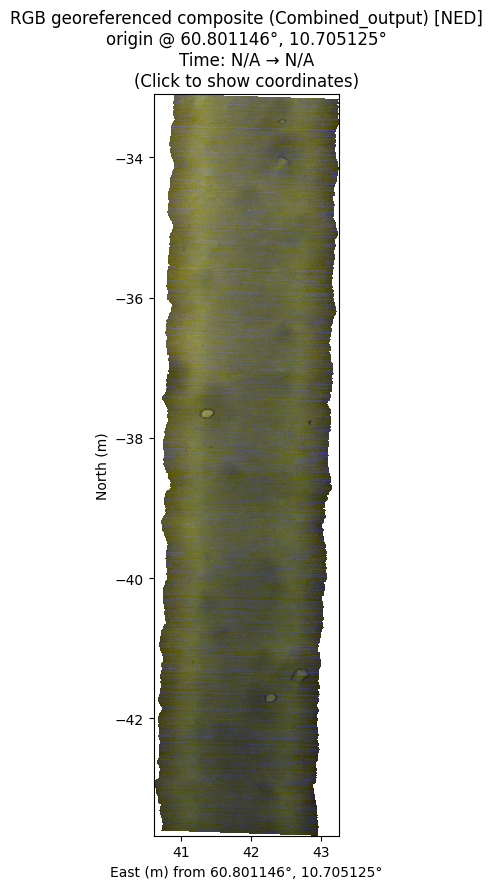

In [9]:
cube.plot_georef(
    coordinate_system="NED",
    track_start=8637,
    track_end=9709,
)

In [16]:
%matplotlib qt

In [13]:
cube.apply_illumination_correction()

✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 6 files...
   rad_uhi_20241029_115057_1: window=1000, strength=1.0
   rad_uhi_20241029_115057_2: window=1000, strength=1.0
   rad_uhi_20241029_115057_3: window=1000, strength=1.0
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_5: window=1000, strength=1.0
   rad_uhi_20241029_115057_6: window=1000, strength=1.0
✅ Loaded illumination correction from disk


array([[[0.0000000e+00, 1.0000000e+00, 1.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 1.0000000e+00],
        [1.0000000e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.0000000e+00, 1.0000000e+00],
        [1.0000000e+00, 1.0000000e+00, 1.0000000e+00, ...,
         0.0000000e+00, 1.0000000e+00, 0.0000000e+00],
        ...,
        [1.0000000e+00, 0.0000000e+00, 1.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [1.0000000e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [1.0000000e+00, 1.0000000e+00, 1.0000000e+00, ...,
         0.0000000e+00, 1.0000000e+00, 0.0000000e+00]],

       [[0.0000000e+00, 0.0000000e+00, 1.4494390e+00, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 5.1726890e-03, 2.6277727e-02, ...,
         0.0000000e+00, 1.3615699e+00, 0.0000000e+00],
        [0.0000000e+00, 4.0959403e-01, 6.8336207e-01, ...,
         0.000

In [14]:
cube.plot_georef(coordinate_system="NED", interactive=True, use_corrected=True)

💡 Interactive mode: Click on the plot to display coordinates



📍 track=187, slit=0
   NED: E=42.76 m, N=49.72 m
   ECEF: X=3065084.38 m, Y=579481.19 m, Z=5544472.42 m
   WGS84: Lat=60.801592°, Lon=10.705910°, h=-135.78 m
   RGB: R=0.432, G=0.361, B=0.001

📍 track=1809, slit=266
   NED: E=42.95 m, N=33.80 m
   ECEF: X=3065100.28 m, Y=579484.39 m, Z=5544468.79 m
   WGS84: Lat=60.801449°, Lon=10.705914°, h=-131.04 m
   RGB: R=0.357, G=0.351, B=0.007

📍 track=3114, slit=88
   NED: E=42.28 m, N=21.02 m
   ECEF: X=3065113.24 m, Y=579486.15 m, Z=5544465.99 m
   WGS84: Lat=60.801335°, Lon=10.705902°, h=-127.10 m
   RGB: R=0.424, G=0.348, B=0.005

📍 track=4034, slit=862
   NED: E=43.97 m, N=11.95 m
   ECEF: X=3065121.80 m, Y=579489.49 m, Z=5544463.53 m
   WGS84: Lat=60.801253°, Lon=10.705933°, h=-124.85 m
   RGB: R=0.388, G=0.347, B=0.000

📍 track=4909, slit=967
   NED: E=44.03 m, N=3.35 m
   ECEF: X=3065129.97 m, Y=579491.09 m, Z=5544460.82 m
   WGS84: Lat=60.801176°, Lon=10.705934°, h=-123.15 m
   RGB: R=0.284, G=0.296, B=0.007

📍 track=5717, slit=644
 

In [17]:
cube.plot_georef(coordinate_system="NED", interactive=True, use_corrected=False)

💡 Interactive mode: Click on the plot to display coordinates


In [15]:
# Debug: Check file boundaries vs actual data shape
print("🔍 Debugging file boundaries:\n")
print(f"Combined data shape: {cube.R.shape if cube.R is not None else 'Not loaded'}")
print(f"\nFile boundaries stored:")
for i, b in enumerate(cube.file_boundaries):
    print(f"  File {i+1}: {b}")

# Check if boundaries match the actual data
if cube.R is not None:
    total_tracks = cube.R.shape[0]
    print(f"\n✅ Total tracks in combined data: {total_tracks}")

    # Verify last boundary
    last_boundary = cube.file_boundaries[-1]
    expected_last = last_boundary["end_track"]
    print(f"📊 Last boundary end_track: {expected_last}")
    print(f"📊 Actual last track index: {total_tracks - 1}")

    if expected_last != total_tracks - 1:
        print(f"❌ MISMATCH! Boundaries don't match data shape!")
    else:
        print(f"✅ Boundaries match data shape")

🔍 Debugging file boundaries:

Combined data shape: (10586, 968)

File boundaries stored:
  File 1: {'file': 'rad_uhi_20241029_115057_1', 'start_track': 0, 'end_track': 1332, 'n_tracks': 1333}
  File 2: {'file': 'rad_uhi_20241029_115057_2', 'start_track': 1333, 'end_track': 3278, 'n_tracks': 1946}
  File 3: {'file': 'rad_uhi_20241029_115057_3', 'start_track': 3279, 'end_track': 5505, 'n_tracks': 2227}
  File 4: {'file': 'rad_uhi_20241029_115057_4', 'start_track': 5506, 'end_track': 7968, 'n_tracks': 2463}
  File 5: {'file': 'rad_uhi_20241029_115057_5', 'start_track': 7969, 'end_track': 10430, 'n_tracks': 2462}
  File 6: {'file': 'rad_uhi_20241029_115057_6', 'start_track': 10431, 'end_track': 10585, 'n_tracks': 155}

✅ Total tracks in combined data: 10586
📊 Last boundary end_track: 10585
📊 Actual last track index: 10585
✅ Boundaries match data shape


In [18]:
# Check RGB intensity ranges across file boundaries
import matplotlib.pyplot as plt

# Get RGB data from cube
R, G, B = cube.R, cube.G, cube.B

# Calculate mean intensity per track (average across slits)
r_mean = np.nanmean(R, axis=1)
g_mean = np.nanmean(G, axis=1)
b_mean = np.nanmean(B, axis=1)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

for i, (channel, color, name) in enumerate(
    [(r_mean, "red", "Red"), (g_mean, "green", "Green"), (b_mean, "blue", "Blue")]
):
    axes[i].plot(channel, color=color, linewidth=0.5, alpha=0.7)
    axes[i].set_ylabel(f"{name} Intensity", fontsize=12)
    axes[i].grid(True, alpha=0.3)

    # Mark file boundaries
    for b in cube.file_boundaries[1:]:
        axes[i].axvline(
            b["start_track"], color="yellow", linestyle=":", linewidth=2, alpha=0.8
        )

    # Show range
    valid_data = channel[np.isfinite(channel)]
    if len(valid_data) > 0:
        axes[i].set_ylim([valid_data.min() * 0.95, valid_data.max() * 1.05])

axes[2].set_xlabel("Track Index", fontsize=12)
axes[0].set_title(
    "RGB Intensity Across Files (Yellow lines = file boundaries)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# Print intensity ranges per file
print("\n📊 Intensity ranges per file:")
for b in cube.file_boundaries:
    start, end = b["start_track"], b["end_track"]
    r_range = (np.nanmin(R[start : end + 1]), np.nanmax(R[start : end + 1]))
    g_range = (np.nanmin(G[start : end + 1]), np.nanmax(G[start : end + 1]))
    b_range = (np.nanmin(B[start : end + 1]), np.nanmax(B[start : end + 1]))
    print(f"\n{b['file']}:")
    print(f"  R: {r_range[0]:.4f} - {r_range[1]:.4f}")
    print(f"  G: {g_range[0]:.4f} - {g_range[1]:.4f}")
    print(f"  B: {b_range[0]:.4f} - {b_range[1]:.4f}")

C:\Users\Erik Liu\AppData\Local\Temp\ipykernel_55796\3861768767.py:8: RuntimeWarning: Mean of empty slice
  r_mean = np.nanmean(R, axis=1)
C:\Users\Erik Liu\AppData\Local\Temp\ipykernel_55796\3861768767.py:9: RuntimeWarning: Mean of empty slice
  g_mean = np.nanmean(G, axis=1)



📊 Intensity ranges per file:

rad_uhi_20241029_115057_1:
  R: 0.1422 - 0.5118
  G: 0.2521 - 0.7233
  B: 0.0000 - 0.0445

rad_uhi_20241029_115057_2:
  R: 0.1214 - 0.6551
  G: 0.2341 - 1.0608
  B: 0.0000 - 0.0444

rad_uhi_20241029_115057_3:
  R: 0.0330 - 0.4335
  G: 0.1026 - 0.6313
  B: 0.0000 - 0.0460

rad_uhi_20241029_115057_4:
  R: 0.0277 - 0.7453
  G: 0.1049 - 1.0540
  B: 0.0000 - 0.0420

rad_uhi_20241029_115057_5:
  R: 0.0882 - 0.4994
  G: 0.1628 - 0.7317
  B: 0.0000 - 0.0424

rad_uhi_20241029_115057_6:
  R: 0.0932 - 0.2339
  G: 0.1965 - 0.3908
  B: 0.0000 - 0.0336


C:\Users\Erik Liu\AppData\Local\Temp\ipykernel_55796\3861768767.py:10: RuntimeWarning: Mean of empty slice
  b_mean = np.nanmean(B, axis=1)


## 🔧 Fix: Per-File Normalization

The color jumps are caused by different radiance levels in each file (different lighting/acquisition conditions).

Solution: Normalize each file's RGB to [0,1] **before** combining them.

In [ ]:
# Test: Check what happens WITHOUT per-file normalization (since files are continuous)
# Just reload to see current state
print(f"Current cube folder: {transect.folder}")
print(f"Number of files: {len(cube.file_boundaries)}")
print(f"\n⚠️ Files are from ONE continuous acquisition, split only for file size")
print("So color jumps are NOT expected at file boundaries...")

## 🔍 Investigation: Why Color Jumps in Continuous Acquisition?

If files are from ONE continuous flight, color jumps could be from:
1. **Altitude/depth changes** - different light attenuation
2. **Water properties** - turbidity, chlorophyll, suspended sediments  
3. **Solar angle changes** - if flight took time, sun position changed
4. **Sensor drift/warm-up** - calibration changes during acquisition
5. **Processing artifacts** - georeferencing interpolation issues

In [19]:
# Test: Check what data attributes cube actually has
print("🔍 Checking cube attributes:")
print(f"  hasattr(cube, 'data'): {hasattr(cube, 'data')}")
print(f"  hasattr(cube, 'R'): {hasattr(cube, 'R')}")
print(f"  hasattr(cube, 'G'): {hasattr(cube, 'G')}")
print(f"  hasattr(cube, 'B'): {hasattr(cube, 'B')}")
print(f"  hasattr(cube, 'wavelengths'): {hasattr(cube, 'wavelengths')}")

if hasattr(cube, "R") and cube.R is not None:
    print(f"\n✅ cube.R shape: {cube.R.shape}")
    print(f"✅ cube.G shape: {cube.G.shape}")
    print(f"✅ cube.B shape: {cube.B.shape}")

if hasattr(cube, "data"):
    print(f"\n❓ cube.data: {cube.data}")
else:
    print(f"\n❌ cube.data does NOT exist!")
    print(f"   → plot_rgb() will FAIL trying to access self.data!")

🔍 Checking cube attributes:
  hasattr(cube, 'data'): False
  hasattr(cube, 'R'): True
  hasattr(cube, 'G'): True
  hasattr(cube, 'B'): True
  hasattr(cube, 'wavelengths'): True

✅ cube.R shape: (10586, 968)
✅ cube.G shape: (10586, 968)
✅ cube.B shape: (10586, 968)

❌ cube.data does NOT exist!
   → plot_rgb() will FAIL trying to access self.data!


In [20]:
# Check if normalization fixed the intensity jumps
R_norm, G_norm, B_norm = cube_normalized.R, cube_normalized.G, cube_normalized.B

print("📊 Intensity ranges per file AFTER per-file normalization:")
for b in cube_normalized.file_boundaries:
    start, end = b["start_track"], b["end_track"]
    r_range = (np.nanmin(R_norm[start : end + 1]), np.nanmax(R_norm[start : end + 1]))
    g_range = (np.nanmin(G_norm[start : end + 1]), np.nanmax(G_norm[start : end + 1]))
    b_range = (np.nanmin(B_norm[start : end + 1]), np.nanmax(B_norm[start : end + 1]))
    print(f"\n{b['file']}:")
    print(f"  R: {r_range[0]:.4f} - {r_range[1]:.4f}")
    print(f"  G: {g_range[0]:.4f} - {g_range[1]:.4f}")
    print(f"  B: {b_range[0]:.4f} - {b_range[1]:.4f}")

print("\n✅ Each file should now be normalized to [0, 1] range!")

NameError: name 'cube_normalized' is not defined

In [ ]:
# Plot the fixed version
cube_normalized.plot_georef(
    coordinate_system="NED", interactive=True, use_corrected=False, normalize=False
)

show with trajectory (require qt)

In [11]:
# Option 1: LATLON mode with trajectory (default)

%matplotlib qt
fig, ax = cube.plot_georef_with_trajectory(
    coordinate_system="LATLON",  # or None
    show_trajectory=True,
    trajectory_color="red",
    trajectory_linewidth=1.5,
    trajectory_alpha=0.7,
    interactive=True,
)

Loaded 232670 navigation records from E:\mjosa_new\navigation_data\nav_data_merged.csv
Time range: 1730196822.84 to 1730207699.44
✓ Added trajectory with 232670 points


get stats for entire transect

In [3]:
print_processing_statistics(track_start=8637, track_end=9709)

PROCESSING STATISTICS

📅 SESSION INFO
  Started: 2025-10-11 16:35:10
  Finished: 2025-10-11 16:44:08
  Processing duration: 8m 57s

⚙️  CONFIGURATION
  Navigation CSV: nav_data_merged.csv
  MBES GeoTIFF: geotiff_2.tif
  Output folder: output
  Max ray length: 100.0 m
  Failure threshold: 50.0%

🧭 NAVIGATION DATA
  Total records: 232,670 (navigation data points in CSV)
  Start time: 1730196822.84 (2024-10-29 10:13:42 UTC)
  End time: 1730207699.44 (2024-10-29 13:14:59 UTC)
  Duration: 10876.6 s (181.3 min)

🗺️  MBES MESH
  Vertices: 7,390,592
  Faces: 7,383,936
  Bounds (X): [592829.45, 592857.59] m
  Bounds (Y): [6741790.71, 6741895.67] m
  Bounds (Z): [-136.01, -110.83] m

📷 CAMERA CALIBRATION
  Focal length: 930.63 px
  Principal point: 484.75 px
  Image width: 968 px

📊 COMBINED TRANSECT STATISTICS (All H5 files together)

  Files processed: 6 total
    ✅ Successful: 6
    ❌ Failed: 0

  HSI Data:
    Total frames: 10,586
    Total rays: 10,247,248
    Successful hits: 10,094,582
  

{'processing_session': {'start_time': '2025-10-11 16:35:10',
  'end_time': '2025-10-11 16:44:08',
  'duration_sec': 537.849462,
  'duration_human': '8m 57s'},
 'configuration': {'nav_csv': 'E:\\mjosa_new\\navigation_data\\nav_data_merged.csv',
  'mbes_geotiff': 'E:\\mjosa_new\\DTM\\geotiff_2.tif',
  'camera_calib_xml': 'E:\\mjosa_new_oct_2025\\anxillary_data\\HSI_2_body.xml',
  'output_folder': 'E:\\mjosa_new_oct_2025\\use_gref4hsi\\057_final\\output',
  'max_ray_length_m': 100.0,
  'early_failure_threshold_pct': 50.0,
  'epsg_mbes': 32632,
  'sensor_translation': [0.0, -2.5, 0.0],
  'sensor_rotation': [[0.0, 1.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, -1.0]]},
 'navigation_data': {'total_records': 232670,
  'time_range': {'start': 1730196822.8426645,
   'end': 1730207699.4423833,
   'duration_sec': 10876.599718809128}},
 'mbes_mesh': {'n_vertices': 7390592,
  'n_faces': 7383936,
  'bounds': {'x_min': 592829.45,
   'x_max': 592857.59,
   'y_min': 6741790.71,
   'y_max': 6741895.67,
   'z_mi

get stats for specific track segment (same as plotting range)

**NEW: This now extracts detailed navigation, coverage, and mission data directly from H5 files!**
- Navigation: depth, roll, pitch, heading statistics
- Mission metrics: distance traveled, average speed
- Coverage: swath width, total area covered
- Shows which H5 files were analyzed for transparency

In [13]:
# Print statistics for the specific track segment you're plotting
# This gives you detailed info about just the area shown in your plot
print_processing_statistics(track_start=8637, track_end=9709)

PROCESSING STATISTICS

📅 SESSION INFO
  Started: 2025-10-11 16:35:10
  Finished: 2025-10-11 16:44:08
  Processing duration: 8m 57s

⚙️  CONFIGURATION
  Navigation CSV: nav_data_merged.csv
  MBES GeoTIFF: geotiff_2.tif
  Output folder: output
  Max ray length: 100.0 m
  Failure threshold: 50.0%

🧭 NAVIGATION DATA
  Total records: 232,670 (navigation data points in CSV)
  Start time: 1730196822.84 (2024-10-29 10:13:42 UTC)
  End time: 1730207699.44 (2024-10-29 13:14:59 UTC)
  Duration: 10876.6 s (181.3 min)

🗺️  MBES MESH
  Vertices: 7,390,592
  Faces: 7,383,936
  Bounds (X): [592829.45, 592857.59] m
  Bounds (Y): [6741790.71, 6741895.67] m
  Bounds (Z): [-136.01, -110.83] m

📷 CAMERA CALIBRATION
  Focal length: 930.63 px
  Principal point: 484.75 px
  Image width: 968 px

📊 COMBINED TRANSECT STATISTICS (All H5 files together)

  Files processed: 6 total
    ✅ Successful: 6
    ❌ Failed: 0

  HSI Data:
    Total frames: 10,586
    Total rays: 10,247,248
    Successful hits: 10,094,582
  

{'processing_session': {'start_time': '2025-10-11 16:35:10',
  'end_time': '2025-10-11 16:44:08',
  'duration_sec': 537.849462,
  'duration_human': '8m 57s'},
 'configuration': {'nav_csv': 'E:\\mjosa_new\\navigation_data\\nav_data_merged.csv',
  'mbes_geotiff': 'E:\\mjosa_new\\DTM\\geotiff_2.tif',
  'camera_calib_xml': 'E:\\mjosa_new_oct_2025\\anxillary_data\\HSI_2_body.xml',
  'output_folder': 'E:\\mjosa_new_oct_2025\\use_gref4hsi\\057_final\\output',
  'max_ray_length_m': 100.0,
  'early_failure_threshold_pct': 50.0,
  'epsg_mbes': 32632,
  'sensor_translation': [0.0, -2.5, 0.0],
  'sensor_rotation': [[0.0, 1.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, -1.0]]},
 'navigation_data': {'total_records': 232670,
  'time_range': {'start': 1730196822.8426645,
   'end': 1730207699.4423833,
   'duration_sec': 10876.599718809128}},
 'mbes_mesh': {'n_vertices': 7390592,
  'n_faces': 7383936,
  'bounds': {'x_min': 592829.45,
   'x_max': 592857.59,
   'y_min': 6741790.71,
   'y_max': 6741895.67,
   'z_mi

plot segment with bombs only

In [8]:
cube.apply_illumination_correction()

✅ Illumination correction already applied with window=1000, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 3 files...
   rad_uhi_20241029_115057_4: window=1000, strength=1.0
   rad_uhi_20241029_115057_5: window=1000, strength=1.0
   rad_uhi_20241029_115057_6: window=1000, strength=1.0
✅ Loaded illumination correction from disk


array([[[0.0000000e+00, 1.0000000e+00, 2.7910578e+00, ...,
         0.0000000e+00, 9.3333578e+00, 0.0000000e+00],
        [5.0372189e-01, 1.1949322e+00, 0.0000000e+00, ...,
         0.0000000e+00, 4.4187975e+00, 0.0000000e+00],
        [2.3675199e+00, 1.3433478e+00, 5.0230107e+00, ...,
         0.0000000e+00, 1.1093828e-02, 0.0000000e+00],
        ...,
        [9.1836733e-01, 3.5065906e+00, 2.1472251e+00, ...,
         0.0000000e+00, 3.2556582e-02, 0.0000000e+00],
        [2.7467301e+00, 0.0000000e+00, 1.2092050e+00, ...,
         0.0000000e+00, 5.5602946e+00, 0.0000000e+00],
        [1.8016024e+00, 5.1010460e-01, 3.5263157e+00, ...,
         0.0000000e+00, 3.1784371e-02, 0.0000000e+00]],

       [[0.0000000e+00, 0.0000000e+00, 1.6821011e+01, ...,
         0.0000000e+00, 9.0247154e+00, 0.0000000e+00],
        [0.0000000e+00, 8.0506790e-01, 1.4819285e+00, ...,
         0.0000000e+00, 3.6709359e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         6.171

In [6]:
# %matplotlib inline
%matplotlib qt

track_start = config.UHI_TRACK_RANGE[0]
track_end = config.UHI_TRACK_RANGE[1]

# Plot WITHOUT alignment shift (original UHI coordinates)
cube.plot_georef(
    coordinate_system="NED",
    show_file_boundaries=True,
    interactive=True,
    track_start=track_start,
    track_end=track_end,
    use_corrected=True,
    apply_alignment_shift=True,  # Original coordinates
)

# Plot WITH alignment shift (shifted to match MBES coordinates)
# Uses UHI_ALIGNMENT_DX=-0.05m and UHI_ALIGNMENT_DY=-3.0m from config

# cube.plot_georef(
#     coordinate_system="NED",
#     show_file_boundaries=True,
#     interactive=True,
#     track_start=track_start,
#     track_end=track_end,
#     use_corrected=True,
#     apply_alignment_shift=True,  # Shifted coordinates (matches detrend_mbes)
# )

💡 Interactive mode: Click on the plot to display coordinates



📍 track=182, slit=656
   NED: E=42.41 m, N=-37.03 m
   ECEF: X=3065165.63 m, Y=579496.23 m, Z=5544448.60 m
   WGS84: Lat=60.800841°, Lon=10.705905°, h=-116.25 m
   RGB: R=0.421, G=0.452, B=0.210

📍 track=288, slit=710
   NED: E=42.55 m, N=-38.08 m
   ECEF: X=3065166.66 m, Y=579496.58 m, Z=5544448.36 m
   WGS84: Lat=60.800831°, Lon=10.705907°, h=-115.94 m
   RGB: R=0.375, G=0.378, B=0.263

📍 track=286, slit=695
   NED: E=42.51 m, N=-38.06 m
   ECEF: X=3065166.66 m, Y=579496.53 m, Z=5544448.38 m
   WGS84: Lat=60.800831°, Lon=10.705907°, h=-115.93 m
   RGB: R=0.366, G=0.399, B=0.391

📍 track=555, slit=268
   NED: E=41.33 m, N=-40.66 m
   ECEF: X=3065169.57 m, Y=579495.88 m, Z=5544447.96 m
   WGS84: Lat=60.800808°, Lon=10.705885°, h=-114.96 m
   RGB: R=0.543, G=0.536, B=0.303

📍 track=829, slit=305
   NED: E=41.35 m, N=-43.34 m
   ECEF: X=3065172.27 m, Y=579496.42 m, Z=5544447.39 m
   WGS84: Lat=60.800784°, Lon=10.705885°, h=-114.11 m
   RGB: R=0.296, G=0.313, B=0.196

📍 track=948, slit=7